In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import datetime as dt
from datetime import datetime
import os
import kagglehub

/Users/davidal-gurnawi/Documents/data_science/machine_learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Change directory to the data location
os.chdir('../../ml_data')

In [3]:
# Read the data
df = pd.read_csv('credit_card_fraud_dataset.csv')
df

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [58]:
# Some data formatting
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['Year'] = df.TransactionDate.dt.year
df['month'] = df.TransactionDate.dt.month 
df['day'] = df.TransactionDate.dt.day 
df['hour'] = df.TransactionDate.dt.hour
df['amount_stan'] = ((df.Amount -df.Amount.mean())/(df.Amount.std()))**2

<Axes: xlabel='month', ylabel='Amount'>

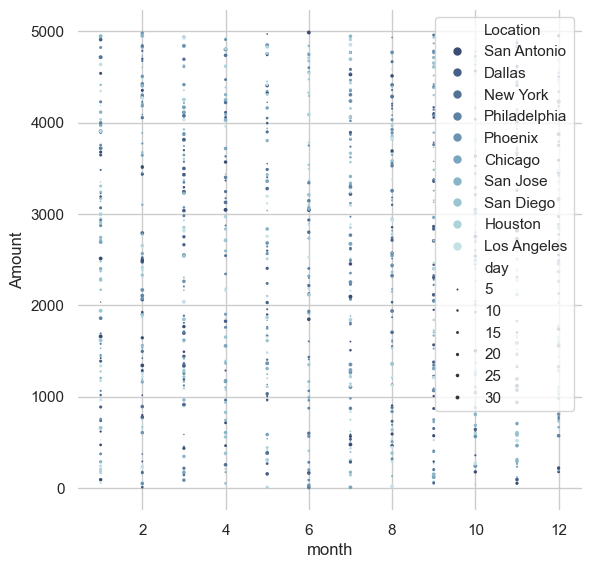

In [59]:
sns.set_theme(style="whitegrid")
df_f = df[df["IsFraud"]==1]
# Draw a scatter plot while assigning point colors and sizes to different
# variables in the dataset
f, ax = plt.subplots(figsize=(6.5, 6.5))
sns.despine(f, left=True, bottom=True)
clarity_ranking = list(df['Location'].unique())
sns.scatterplot(x="month", y="Amount",
                hue="Location", size="day",
                palette="ch:r=-.2,d=.3_r",
                hue_order=clarity_ranking,
                sizes=(1, 8), linewidth=0,
                data=df_f, ax=ax)


In [60]:
data = pd.pivot_table(df_f, index='month',columns='hour', values='amount_stan', aggfunc='mean', fill_value=0)

In [61]:
data

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
month,,,,,,,,,,,,,,,,,,,,,
1,0.000000,1.597310,1.012596,0.602633,1.383524,1.523824,1.422532,0.989036,1.266489,0.731863,...,1.511392,0.348111,0.197114,1.560450,1.094860,1.199704,0.207137,0.502668,0.916499,1.171773
2,0.780074,0.913630,1.374197,2.609123,0.646172,1.903542,1.457318,1.803341,1.974631,1.329510,...,0.420103,0.989494,1.466266,1.403363,0.563661,0.556330,1.313183,1.754067,1.440989,0.961729
3,0.906158,0.889689,0.897163,1.321088,1.154930,1.524204,0.623900,0.558773,0.778696,0.992206,...,0.000000,0.170938,1.128432,1.075761,1.096398,0.628997,0.598255,0.822336,0.847304,1.480506
4,1.148318,0.694230,1.467674,1.454843,0.890320,0.077712,0.767137,0.587722,1.433722,1.368710,...,1.290254,0.749525,0.720550,0.000000,0.767095,1.275725,1.518331,1.147824,2.800705,1.558455
5,0.427668,0.004924,0.140389,2.160344,0.822690,0.184274,1.833102,0.327510,1.430789,0.882025,...,0.675202,1.581576,1.326782,1.635818,1.049615,0.945145,0.850082,0.796772,2.135252,0.726970
6,0.257498,0.477239,0.115861,1.608526,0.836179,1.555022,1.329395,0.630708,1.963255,0.984445,...,0.853328,0.000000,1.863598,1.903736,1.773984,0.898686,0.176263,0.047541,0.152693,1.136396
7,1.111257,1.655010,0.920838,1.860124,1.135045,1.355668,1.288608,1.609568,0.863986,0.305702,...,0.446055,1.623683,0.775718,1.419949,0.891093,1.506770,0.929580,0.259696,0.377119,1.240069
8,0.539646,0.850082,0.856899,1.183526,0.665322,1.029942,0.841494,0.882193,0.158953,0.740526,...,0.739419,1.078031,1.242073,1.452102,0.838909,1.530027,1.052302,0.000000,0.603583,0.461095
9,0.580219,0.809161,0.768812,2.059177,0.070226,0.000000,1.247158,0.794224,1.093942,1.175929,...,1.728109,0.795123,0.651180,2.515354,0.583947,1.247722,1.667926,0.000000,0.557871,1.772294


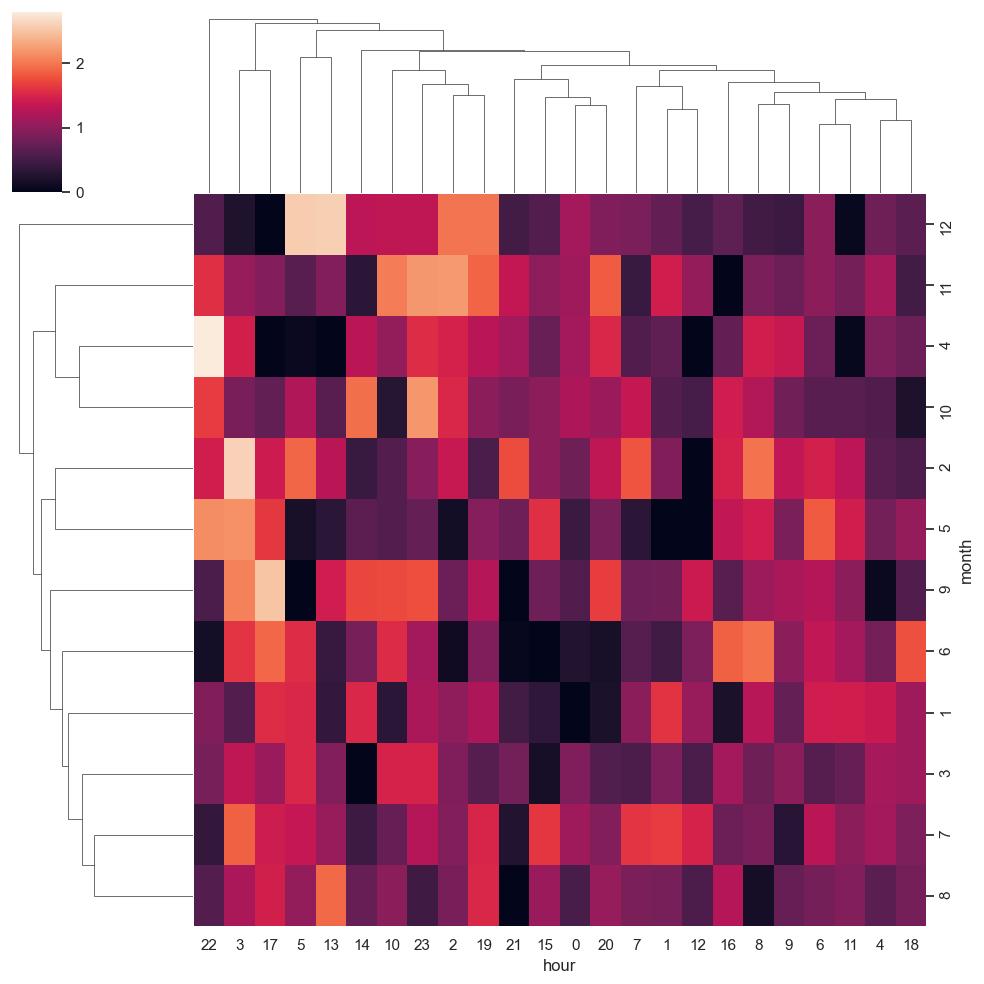

In [62]:
sns.clustermap(data)